# Sparse Operators and Oracle Assumptions

This tutorial clarifies the boundary between the package's finite dense demonstrations and scalable QSVT algorithms.

Goals:

- compare dense matrix access with sparse/oracle-style access assumptions
- identify which costs are visible in the package's resource proxies
- identify which costs remain outside the implemented notebooks
- keep benchmark and tutorial interpretation honest

No scalable sparse oracle is constructed here. The notebook is an assumption map for reading QSVT reports and benchmark proxies.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_positive_inverse_polynomial
from qsvt.resources import qsvt_resource_report

np.set_printoptions(precision=4, suppress=True)

## Access Models

The same polynomial degree can mean different things under different access assumptions. A dense educational notebook can materialize a full matrix. A scalable QSVT algorithm needs a block encoding supplied by an oracle, sparse-access construction, or problem-specific circuit.

In [2]:
access_models = [
    {
        "model": "dense finite matrix",
        "implemented_here": "yes",
        "visible_cost": "matrix dimension and dense validation",
        "omitted_cost": "scalable data loading",
    },
    {
        "model": "explicit dense block encoding",
        "implemented_here": "finite only",
        "visible_cost": "unitary dimension and block error",
        "omitted_cost": "asymptotic oracle construction",
    },
    {
        "model": "sparse-access block encoding",
        "implemented_here": "no",
        "visible_cost": "degree and signal-call proxy only",
        "omitted_cost": "row oracle, value oracle, normalization",
    },
    {
        "model": "end-to-end quantum workflow",
        "implemented_here": "no",
        "visible_cost": "not estimated",
        "omitted_cost": "state preparation, readout, amplification",
    },
]

columns = ["model", "implemented_here", "visible_cost", "omitted_cost"]
widths = {
    key: max(len(key), *(len(str(row[key])) for row in access_models))
    for key in columns
}
print("  ".join(key.ljust(widths[key]) for key in columns))
print("  ".join("-" * widths[key] for key in columns))
for row in access_models:
    print("  ".join(str(row[key]).ljust(widths[key]) for key in columns))

model                          implemented_here  visible_cost                           omitted_cost                             
-----------------------------  ----------------  -------------------------------------  -----------------------------------------
dense finite matrix            yes               matrix dimension and dense validation  scalable data loading                    
explicit dense block encoding  finite only       unitary dimension and block error      asymptotic oracle construction           
sparse-access block encoding   no                degree and signal-call proxy only      row oracle, value oracle, normalization  
end-to-end quantum workflow    no                not estimated                          state preparation, readout, amplification


## Resource Proxy Fields

`qsvt_resource_report` reports polynomial-level quantities. These are useful, but they are not hardware runtime estimates.

In [3]:
degrees = [5, 9, 13, 17]
matrix_dimensions = [8, 16, 32, 64]
reports = []

for degree, dimension in zip(degrees, matrix_dimensions, strict=True):
    coeffs = design_positive_inverse_polynomial(
        gamma=0.2,
        degree=degree,
        num_points=401,
    )
    reports.append(
        qsvt_resource_report(
            coeffs,
            matrix_dimension=dimension,
            attempt_synthesis=False,
        )
    )

for report in reports:
    resources = report["resources"]
    print(
        "dimension=",
        resources["matrix_dimension"],
        "degree=",
        resources["degree"],
        "signal_calls=",
        resources["signal_operator_calls"],
        "encoding_qubits=",
        resources["encoding_qubits"],
    )

dimension= 8 degree= 4 signal_calls= 4 encoding_qubits= 3
dimension= 16 degree= 9 signal_calls= 9 encoding_qubits= 4
dimension= 32 degree= 13 signal_calls= 13 encoding_qubits= 5
dimension= 64 degree= 16 signal_calls= 16 encoding_qubits= 6


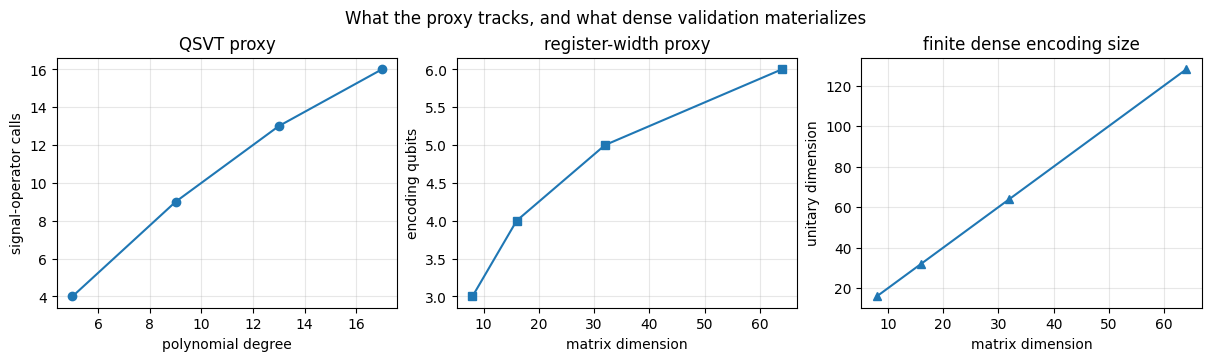

In [4]:
signal_calls = [report["resources"]["signal_operator_calls"] for report in reports]
encoding_qubits = [report["resources"]["encoding_qubits"] for report in reports]
dense_unitary_dimensions = [2 * dimension for dimension in matrix_dimensions]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)

axes[0].plot(degrees, signal_calls, "o-")
axes[0].set_xlabel("polynomial degree")
axes[0].set_ylabel("signal-operator calls")
axes[0].set_title("QSVT proxy")
axes[0].grid(alpha=0.3)

axes[1].plot(matrix_dimensions, encoding_qubits, "s-")
axes[1].set_xlabel("matrix dimension")
axes[1].set_ylabel("encoding qubits")
axes[1].set_title("register-width proxy")
axes[1].grid(alpha=0.3)

axes[2].plot(
    matrix_dimensions, dense_unitary_dimensions, "^-", label="dense finite unitary"
)
axes[2].set_xlabel("matrix dimension")
axes[2].set_ylabel("unitary dimension")
axes[2].set_title("finite dense encoding size")
axes[2].grid(alpha=0.3)

fig.suptitle("What the proxy tracks, and what dense validation materializes")
plt.show()

## Reading Truth Contracts

The resource reports explicitly list omitted costs. This is the key distinction between a useful QSVT proxy and an end-to-end quantum algorithm claim.

In [5]:
sample_contract = reports[-1]["truth_contract"]
sample_resources = reports[-1]["resources"]

print("implementation_kind:", sample_contract["implementation_kind"])
print("truth_status:", sample_contract["truth_status"])
print("requires_block_encoding:", sample_resources["requires_block_encoding"])
print("requires_state_preparation:", sample_resources["requires_state_preparation"])
print("omitted_costs:")
for item in sample_resources["omitted_costs"]:
    print(" -", item)

implementation_kind: polynomial-resource-proxy
truth_status: proxy_only
requires_block_encoding: True
requires_state_preparation: True
omitted_costs:
 - block_encoding_construction
 - state_preparation
 - amplitude_amplification
 - error_correction
 - hardware_compilation


## Validation

These checks make sure the tutorial is showing proxy fields rather than accidentally treating the report as an end-to-end estimate.

In [6]:
assert sample_contract["is_end_to_end_quantum_resource_estimate"] is False
assert sample_resources["requires_block_encoding"] is True
assert sample_resources["requires_state_preparation"] is True
assert "block_encoding_construction" in sample_resources["omitted_costs"]
reported_degrees = [report["resources"]["degree"] for report in reports]
assert signal_calls == reported_degrees
assert all(
    actual <= requested
    for actual, requested in zip(reported_degrees, degrees, strict=True)
)

print("validation: passed")

validation: passed
